In [24]:
spaerman_correlation = {
  "Postgres (v16)": {
    "JOB-Light": 0.83,
    "JOB": 0.55,
    "JOB-Complex": 0.29
  },
  "DACE": {
    "JOB-Light": 0.31,
    "JOB": 0.26,
    "JOB-Complex": -0.05
  },
  "T3": {
    "JOB-Light": 0.37,
    "JOB": 0.38,
    "JOB-Complex": 0.08
  },
  "Zero-Shot": {
    "JOB-Light": 0.8,
    "JOB": 0.49,
    "JOB-Complex": 0.4
  }
}

surpassed_plans = {
  "Postgres (v16)": {
    "JOB-Light": 0.98,
    "JOB": 0.86,
    "JOB-Complex": 0.54
  },
  "DACE": {
    "JOB-Light": 0.81,
    "JOB": 0.80,
    "JOB-Complex": 0.54
  },
  "T3": {
    "JOB-Light": 0.71,
    "JOB": 0.86,
    "JOB-Complex": 0.61
  },
  "Zero-Shot": {
    "JOB-Light": 0.93,
    "JOB": 0.83,
    "JOB-Complex": 0.55
  }
}

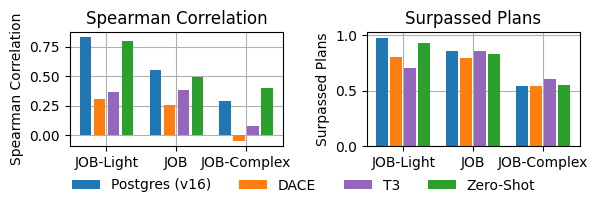

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the dictionaries to DataFrames for easier plotting
spaerman_df = pd.DataFrame(spaerman_correlation).T.reset_index().rename(columns={'index': 'Method'})
surpassed_df = pd.DataFrame(surpassed_plans).T.reset_index().rename(columns={'index': 'Method'})

# Melt the DataFrames for plotting
spaerman_melted = spaerman_df.melt(id_vars='Method', var_name='Group', value_name='Spearman Correlation')
surpassed_melted = surpassed_df.melt(id_vars='Method', var_name='Group', value_name='Surpassed Plans')

# Create the multiplot
fig, axes = plt.subplots(1, 2, figsize=(6, 2))

colors = {
    'Postgres (v16)': 'C0',
    'DACE': 'C1',
    'Zero-Shot': 'C2',
    'T3': 'C4'
}

# Plot Spearman Correlation
for i, method in enumerate(spaerman_melted['Method'].unique()):
    method_data = spaerman_melted[spaerman_melted['Method'] == method]
    x = [0, 1.5, 3]  # Positions for JOB-Light, JOB, JOB-Complex with added space
    axes[0].bar([pos + i * 0.3 for pos in x], method_data['Spearman Correlation'], width=0.25, label=method, color=colors[method])

axes[0].set_title('Spearman Correlation')
axes[0].set_xticks([0.45, 1.95, 3.45])
axes[0].set_xticklabels(['JOB-Light', 'JOB', 'JOB-Complex'])
axes[0].set_ylabel('Spearman Correlation')
axes[0].set_axisbelow(True)
axes[0].grid(True)
axes[1].set_axisbelow(True)
axes[1].grid(True)

# Plot Surpassed Plans
for i, method in enumerate(surpassed_melted['Method'].unique()):
    method_data = surpassed_melted[surpassed_melted['Method'] == method]
    x = [0, 1.5, 3]  # Positions for JOB-Light, JOB, JOB-Complex with added space
    axes[1].bar([pos + i * 0.3 for pos in x], method_data['Surpassed Plans'], width=0.25, label=method, color=colors[method])

axes[1].set_title('Surpassed Plans')
axes[1].set_xticks([0.45, 1.95, 3.45])
axes[1].set_xticklabels(['JOB-Light', 'JOB', 'JOB-Complex'])
axes[1].set_ylabel('Surpassed Plans')

# Use a common legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('correlation.pdf', bbox_inches='tight')
plt.show()
